In [1]:
from pathlib import Path
import pandas as pd

DATA_ROOT = Path("../data/raw/mimic-iv")

print(DATA_ROOT)
print(list(DATA_ROOT.iterdir()))

../data/raw/mimic-iv
[PosixPath('../data/raw/mimic-iv/hosp'), PosixPath('../data/raw/mimic-iv/icu')]


In [2]:
for module in ["hosp", "icu"]:
    path = DATA_ROOT / module
    
    print(f"\n===== {module.upper()} =====")
    
    for file in sorted(path.glob("*.csv.gz")):
        print(file.name)


===== HOSP =====
admissions.csv.gz
d_hcpcs.csv.gz
d_icd_diagnoses.csv.gz
d_icd_procedures.csv.gz
d_labitems.csv.gz
diagnoses_icd.csv.gz
drgcodes.csv.gz
emar.csv.gz
emar_detail.csv.gz
hcpcsevents.csv.gz
labevents.csv.gz
microbiologyevents.csv.gz
omr.csv.gz
patients.csv.gz
pharmacy.csv.gz
poe.csv.gz
poe_detail.csv.gz
prescriptions.csv.gz
procedures_icd.csv.gz
provider.csv.gz
services.csv.gz
transfers.csv.gz

===== ICU =====
caregiver.csv.gz
chartevents.csv.gz
d_items.csv.gz
datetimeevents.csv.gz
icustays.csv.gz
ingredientevents.csv.gz
inputevents.csv.gz
outputevents.csv.gz
procedureevents.csv.gz


In [3]:
patients = pd.read_csv(DATA_ROOT / "hosp" / "patients.csv.gz")
admissions = pd.read_csv(DATA_ROOT / "hosp" / "admissions.csv.gz")

icustays = pd.read_csv(DATA_ROOT / "icu" / "icustays.csv.gz")

In [4]:
print("patients:", patients.shape)
print("admissions:", admissions.shape)
print("icustays:", icustays.shape)

patients: (100, 6)
admissions: (275, 16)
icustays: (140, 8)


In [5]:
display(patients.head())
display(admissions.head())
display(icustays.head())

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


In [6]:
print("PATIENTS")
print(patients.columns.tolist())

print("\nADMISSIONS")
print(admissions.columns.tolist())

print("\nICUSTAYS")
print(icustays.columns.tolist())

PATIENTS
['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']

ADMISSIONS
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']

ICUSTAYS
['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los']


In [7]:
chartevents = pd.read_csv(
    DATA_ROOT / "icu" / "chartevents.csv.gz",
    nrows=10000
)

display(chartevents.head())

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,225054,On,NaN,NaN,0.0
1,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:43:00,223769,100,100.0,%,0.0
2,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,223956,Atrial demand,NaN,NaN,0.0
3,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224866,Yes,NaN,NaN,0.0
4,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,227341,No,0.0,NaN,0.0


In [8]:
print(chartevents.columns.tolist())

['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime', 'storetime', 'itemid', 'value', 'valuenum', 'valueuom', 'warning']


In [9]:
d_items = pd.read_csv(
    DATA_ROOT / "icu" / "d_items.csv.gz"
)

print(d_items.shape)
display(d_items.head())

(4014, 9)


,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,226228,Gender,Gender,chartevents,ADT,NaN,Text,NaN,NaN
1,226545,Race,Race,chartevents,ADT,NaN,Text,NaN,NaN
2,229877,Suction events (CH),Suction events (CH),chartevents,ECMO,NaN,Text,NaN,NaN
3,229875,Oxygenator visible (CH),Oxygenator visible (CH),chartevents,ECMO,NaN,Text,NaN,NaN
4,229266,Cannula sites visually inspected (ECMO),Cannula sites visually inspected (ECMO),chartevents,ECMO,NaN,Text,NaN,NaN


In [10]:
d_items[
    d_items["label"].str.contains(
        "heart rate|arterial blood pressure|mean arterial|oxygen saturation|glasgow",
        case=False,
        na=False
    )
][
    ["itemid", "label", "abbreviation", "unitname"]
].head(100)

,itemid,label,abbreviation,unitname
1567,228232,PAR-Oxygen saturation,PAR-Oxygen saturation,NaN
2054,220047,Heart Rate Alarm - Low,HR Alarm - Low,bpm
2055,220058,Arterial Blood Pressure Alarm - High,ABP Alarm - High,mmHg
2057,220056,Arterial Blood Pressure Alarm - Low,ABP Alarm - Low,mmHg
2063,220046,Heart rate Alarm - High,HR Alarm - High,bpm
2566,220052,Arterial Blood Pressure mean,ABPm,mmHg
2572,220051,Arterial Blood Pressure diastolic,ABPd,mmHg
2577,220045,Heart Rate,HR,bpm
2586,220050,Arterial Blood Pressure systolic,ABPs,mmHg


In [11]:
gcs_items = d_items[
    d_items["label"].str.contains(
        "glasgow",
        case=False,
        na=False
    )
]

display(gcs_items[
    ["itemid", "label", "abbreviation", "unitname"]
])

,itemid,label,abbreviation,unitname


In [12]:
# Load the item dictionary
d_items = pd.read_csv(
    DATA_ROOT / "icu" / "d_items.csv.gz"
)

print("Total item definitions:", len(d_items))

# Search for important physiological and neurological measurements

keywords = [
    "heart rate",
    "respiratory rate",
    "oxygen saturation",
    "spo2",
    "mean arterial",
    "arterial blood pressure",
    "blood pressure",
    "glasgow",
    "gcs",
    "mental status",
]

for keyword in keywords:
    matches = d_items[
        d_items["label"]
        .fillna("")
        .str.contains(keyword, case=False, na=False)
    ]

    print(f"\n{'='*70}")
    print(f"SEARCH: {keyword.upper()}")
    print(f"Matches: {len(matches)}")

    display(
        matches[
            ["itemid", "label", "abbreviation", "unitname", "category"]
        ].head(30)
    )

Total item definitions: 4014

SEARCH: HEART RATE
Matches: 3


,itemid,label,abbreviation,unitname,category
2054,220047,Heart Rate Alarm - Low,HR Alarm - Low,bpm,Alarms
2063,220046,Heart rate Alarm - High,HR Alarm - High,bpm,Alarms
2577,220045,Heart Rate,HR,bpm,Routine Vital Signs



SEARCH: RESPIRATORY RATE
Matches: 4


,itemid,label,abbreviation,unitname,category
2284,224688,Respiratory Rate (Set),Respiratory Rate (Set),insp/min,Respiratory
2314,224690,Respiratory Rate (Total),Respiratory Rate (Total),insp/min,Respiratory
2329,220210,Respiratory Rate,RR,insp/min,Respiratory
2344,224689,Respiratory Rate (spontaneous),Respiratory Rate (spontaneous),insp/min,Respiratory



SEARCH: OXYGEN SATURATION
Matches: 1


...

,itemid,label,abbreviation,unitname,category



SEARCH: GCS
Matches: 12


,itemid,label,abbreviation,unitname,category
621,223901,GCS - Motor Response,Motor Response,NaN,Neurological
627,223900,GCS - Verbal Response,Verbal Response,NaN,Neurological
639,220739,GCS - Eye Opening,Eye Opening,NaN,Neurological
1494,228112,GCSVerbalApacheIIValue (intubated),GCSVerbalApacheIIValue (intubated),NaN,Scores - APACHE II
1495,226757,GCSMotorApacheIIValue,GCSMotorApacheIIValue,NaN,Scores - APACHE II
1497,226758,GCSVerbalApacheIIValue,GCSVerbalApacheIIValue,NaN,Scores - APACHE II
1500,226756,GCSEyeApacheIIValue,GCSEyeApacheIIValue,NaN,Scores - APACHE II
1574,227011,GCSEye_ApacheIV,GCSEye_ApacheIV,NaN,Scores - APACHE IV (2)
1576,227012,GCSMotor_ApacheIV,GCSMotor_ApacheIV,NaN,Scores - APACHE IV (2)
1577,227014,GCSVerbal_ApacheIV,GCSVerbal_ApacheIV,NaN,Scores - APACHE IV (2)



SEARCH: MENTAL STATUS
Matches: 7


,itemid,label,abbreviation,unitname,category
240,228977,Altered Mental Status NCP - Interventions,AMS NCP - Interventions,NaN,Care Plans
241,229089,Altered Mental Status NCP - Problem resolved,AMS NCP - Problem resolved,NaN,Care Plans
247,229088,Altered Mental Status NCP - Plan revised,AMS NCP - Plan revised,NaN,Care Plans
260,228973,Altered Mental Status NCP - Expected outcomes,AMS NCP - Expected outcomes,NaN,Care Plans
277,228975,Altered Mental Status NCP - Goal,AMS NCP - Goal,NaN,Care Plans
358,228979,Altered Mental Status NCP - outcomes met,AMS NCP - outcomes met,NaN,Care Plans
1833,227346,Mental status,Mental status,NaN,Restraint/Support Systems


In [14]:
# Search d_items for ECG / waveform-related concepts

ecg_matches = d_items[
    d_items["label"]
    .fillna("")
    .str.contains(
        "ecg|electrocard|ekg|rhythm",
        case=False,
        na=False
    )
]

display(
    ecg_matches[
        ["itemid", "label", "abbreviation", "unitname", "category"]
    ].to_string(index=False)
)

' itemid        label abbreviation unitname            category\n 220048 Heart Rhythm Heart Rhythm      NaN Routine Vital Signs\n 225402          EKG          EKG      NaN        4-Procedures'

In [16]:
# How many unique item IDs are represented in our sample?

print("Unique item IDs in sample:", chartevents["itemid"].nunique())

# Join sample chart events with item dictionary

chart_sample = chartevents.merge(
    d_items[
        ["itemid", "label", "abbreviation", "unitname", "category"]
    ],
    on="itemid",
    how="left"
)

display(
    chart_sample[
        [
            "charttime",
            "stay_id",
            "itemid",
            "label",
            "valuenum",
            "valueuom"
        ]
    ].head(30)
)

Unique item IDs in sample: 554


,charttime,stay_id,itemid,label,valuenum,valueuom
0,2132-12-16 00:00:00,32604416,225054,Anti Embolic Device Status,NaN,NaN
1,2132-12-16 00:00:00,32604416,223769,O2 Saturation Pulseoxymetry Alarm - High,100.0,%
2,2132-12-16 00:00:00,32604416,223956,Temporary Pacemaker Mode,NaN,NaN
3,2132-12-16 00:00:00,32604416,224866,Temporary Atrial Capture,NaN,NaN
4,2132-12-16 00:00:00,32604416,227341,History of falling (within 3 mnths),0.0,NaN
5,2132-12-16 00:00:00,32604416,224751,Temporary Pacemaker Rate,52.0,bpm
6,2132-12-16 00:00:00,32604416,227969,Safety Measures,NaN,NaN
7,2132-12-16 00:00:00,32604416,223935,PostTib. Pulses R,NaN,NaN
8,2132-12-16 00:00:00,32604416,223782,Pain Type,NaN,NaN
9,2132-12-16 00:00:00,32604416,224773,LLE Temp,NaN,NaN


In [17]:
hr_sample = chart_sample[
    chart_sample["label"]
    .fillna("")
    .str.contains(
        "heart rate",
        case=False,
        na=False
    )
]

print("Heart-rate observations in sample:", len(hr_sample))

display(hr_sample.head(20))

Heart-rate observations in sample: 266


,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,label,abbreviation,unitname,category
11,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:41:00,220047,55,55.0,bpm,0.0,Heart Rate Alarm - Low,HR Alarm - Low,bpm,Alarms
36,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:41:00,220046,120,120.0,bpm,0.0,Heart rate Alarm - High,HR Alarm - High,bpm,Alarms
69,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220045,80,80.0,bpm,0.0,Heart Rate,HR,bpm,Routine Vital Signs
102,10005817,20626031,32604416,6770.0,2132-12-16 01:00:00,2132-12-16 01:04:00,220045,82,82.0,bpm,0.0,Heart Rate,HR,bpm,Routine Vital Signs
122,10005817,20626031,32604416,6770.0,2132-12-16 02:00:00,2132-12-16 02:11:00,220045,80,80.0,bpm,0.0,Heart Rate,HR,bpm,Routine Vital Signs
135,10005817,20626031,32604416,6770.0,2132-12-16 03:00:00,2132-12-16 03:00:00,220045,78,78.0,bpm,0.0,Heart Rate,HR,bpm,Routine Vital Signs
169,10005817,20626031,32604416,6770.0,2132-12-16 04:00:00,2132-12-16 04:21:00,220045,84,84.0,bpm,0.0,Heart Rate,HR,bpm,Routine Vital Signs
193,10005817,20626031,32604416,6770.0,2132-12-16 05:00:00,2132-12-16 05:00:00,220045,81,81.0,bpm,0.0,Heart Rate,HR,bpm,Routine Vital Signs
208,10005817,20626031,32604416,6770.0,2132-12-16 06:00:00,2132-12-16 06:00:00,220045,88,88.0,bpm,0.0,Heart Rate,HR,bpm,Routine Vital Signs
224,10005817,20626031,32604416,79166.0,2132-12-16 07:00:00,2132-12-16 07:11:00,220045,80,80.0,bpm,0.0,Heart Rate,HR,bpm,Routine Vital Signs


In [18]:
gcs_items = d_items[
    d_items["label"]
    .fillna("")
    .str.contains(
        "glasgow|gcs",
        case=False,
        na=False
    )
]

display(
    gcs_items[
        ["itemid", "label", "abbreviation", "unitname", "category"]
    ].to_string(index=False)
)

' itemid                              label                       abbreviation unitname               category\n 223901               GCS - Motor Response                     Motor Response      NaN           Neurological\n 223900              GCS - Verbal Response                    Verbal Response      NaN           Neurological\n 220739                  GCS - Eye Opening                        Eye Opening      NaN           Neurological\n 228112 GCSVerbalApacheIIValue (intubated) GCSVerbalApacheIIValue (intubated)      NaN     Scores - APACHE II\n 226757              GCSMotorApacheIIValue              GCSMotorApacheIIValue      NaN     Scores - APACHE II\n 226758             GCSVerbalApacheIIValue             GCSVerbalApacheIIValue      NaN     Scores - APACHE II\n 226756                GCSEyeApacheIIValue                GCSEyeApacheIIValue      NaN     Scores - APACHE II\n 227011                    GCSEye_ApacheIV                    GCSEye_ApacheIV      NaN Scores - APACHE IV (2)\n

In [19]:
diagnoses = pd.read_csv(
    DATA_ROOT / "hosp" / "diagnoses_icd.csv.gz"
)

d_icd = pd.read_csv(
    DATA_ROOT / "hosp" / "d_icd_diagnoses.csv.gz"
)

print("diagnoses:", diagnoses.shape)
print("d_icd:", d_icd.shape)

diagnoses: (4506, 5)
d_icd: (109775, 3)


In [20]:
display(diagnoses.head())
display(d_icd.head())

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,4139,9
1,10035185,22580999,10,V707,9
2,10035185,22580999,1,41401,9
3,10035185,22580999,9,3899,9
4,10035185,22580999,11,V8532,9


,icd_code,icd_version,long_title
0,0090,9,"Infectious colitis, enteritis, and gastroenter..."
1,01160,9,"Tuberculous pneumonia [any form], unspecified"
2,01186,9,"Other specified pulmonary tuberculosis, tuberc..."
3,01200,9,"Tuberculous pleurisy, unspecified"
4,01236,9,"Tuberculous laryngitis, tubercle bacilli not f..."


In [21]:
diagnosis_details = diagnoses.merge(
    d_icd,
    on=["icd_code", "icd_version"],
    how="left"
)

print(diagnosis_details.columns.tolist())

['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version', 'long_title']


In [22]:
display(
    diagnosis_details[
        ["subject_id", "hadm_id", "icd_code", "icd_version", "long_title"]
    ].head(30)
)

,subject_id,hadm_id,icd_code,icd_version,long_title
0,10035185,22580999,4139,9,Other and unspecified angina pectoris
1,10035185,22580999,V707,9,Examination of participant in clinical trial
2,10035185,22580999,41401,9,Coronary atherosclerosis of native coronary ar...
3,10035185,22580999,3899,9,Unspecified hearing loss
4,10035185,22580999,V8532,9,"Body Mass Index 32.0-32.9, adult"
5,10035185,22580999,25002,9,Diabetes mellitus without mention of complicat...
6,10035185,22580999,71696,9,"Arthropathy, unspecified, lower leg"
7,10035185,22580999,V1083,9,Personal history of other malignant neoplasm o...
8,10035185,22580999,2724,9,Other and unspecified hyperlipidemia
9,10035185,22580999,V5867,9,Long-term (current) use of insulin


In [ ]:
# Load the item dictionary
d_items = pd.read_csv(
    DATA_ROOT / "icu" / "d_items.csv.gz"
)

print("Total item definitions:", len(d_items))

# Search for important physiological and neurological measurements

keywords = [
    "heart rate",
    "respiratory rate",
    "oxygen saturation",
    "spo2",
    "mean arterial",
    "arterial blood pressure",
    "blood pressure",
    "glasgow",
    "gcs",
    "mental status",
]

for keyword in keywords:
    matches = d_items[
        d_items["label"]
        .fillna("")
        .str.contains(keyword, case=False, na=False)
    ]

    print(f"\n{'='*70}")
    print(f"SEARCH: {keyword.upper()}")
    print(f"Matches: {len(matches)}")

    display(
        matches[
            ["itemid", "label", "abbreviation", "unitname", "category"]
        ].head(30)
    )

Total item definitions: 4014

SEARCH: HEART RATE
Matches: 3


,itemid,label,abbreviation,unitname,category
2054,220047,Heart Rate Alarm - Low,HR Alarm - Low,bpm,Alarms
2063,220046,Heart rate Alarm - High,HR Alarm - High,bpm,Alarms
2577,220045,Heart Rate,HR,bpm,Routine Vital Signs



SEARCH: RESPIRATORY RATE
Matches: 4


,itemid,label,abbreviation,unitname,category
2284,224688,Respiratory Rate (Set),Respiratory Rate (Set),insp/min,Respiratory
2314,224690,Respiratory Rate (Total),Respiratory Rate (Total),insp/min,Respiratory
2329,220210,Respiratory Rate,RR,insp/min,Respiratory
2344,224689,Respiratory Rate (spontaneous),Respiratory Rate (spontaneous),insp/min,Respiratory



SEARCH: OXYGEN SATURATION
Matches: 1


...

,itemid,label,abbreviation,unitname,category



SEARCH: GCS
Matches: 12


,itemid,label,abbreviation,unitname,category
621,223901,GCS - Motor Response,Motor Response,NaN,Neurological
627,223900,GCS - Verbal Response,Verbal Response,NaN,Neurological
639,220739,GCS - Eye Opening,Eye Opening,NaN,Neurological
1494,228112,GCSVerbalApacheIIValue (intubated),GCSVerbalApacheIIValue (intubated),NaN,Scores - APACHE II
1495,226757,GCSMotorApacheIIValue,GCSMotorApacheIIValue,NaN,Scores - APACHE II
1497,226758,GCSVerbalApacheIIValue,GCSVerbalApacheIIValue,NaN,Scores - APACHE II
1500,226756,GCSEyeApacheIIValue,GCSEyeApacheIIValue,NaN,Scores - APACHE II
1574,227011,GCSEye_ApacheIV,GCSEye_ApacheIV,NaN,Scores - APACHE IV (2)
1576,227012,GCSMotor_ApacheIV,GCSMotor_ApacheIV,NaN,Scores - APACHE IV (2)
1577,227014,GCSVerbal_ApacheIV,GCSVerbal_ApacheIV,NaN,Scores - APACHE IV (2)



SEARCH: MENTAL STATUS
Matches: 7


,itemid,label,abbreviation,unitname,category
240,228977,Altered Mental Status NCP - Interventions,AMS NCP - Interventions,NaN,Care Plans
241,229089,Altered Mental Status NCP - Problem resolved,AMS NCP - Problem resolved,NaN,Care Plans
247,229088,Altered Mental Status NCP - Plan revised,AMS NCP - Plan revised,NaN,Care Plans
260,228973,Altered Mental Status NCP - Expected outcomes,AMS NCP - Expected outcomes,NaN,Care Plans
277,228975,Altered Mental Status NCP - Goal,AMS NCP - Goal,NaN,Care Plans
358,228979,Altered Mental Status NCP - outcomes met,AMS NCP - outcomes met,NaN,Care Plans
1833,227346,Mental status,Mental status,NaN,Restraint/Support Systems


In [23]:
sepsis_diagnoses = diagnosis_details[
    diagnosis_details["long_title"]
    .fillna("")
    .str.contains(
        "sepsis|septic",
        case=False,
        na=False
    )
]

print("Sepsis-related diagnosis rows:", len(sepsis_diagnoses))

display(
    sepsis_diagnoses[
        [
            "subject_id",
            "hadm_id",
            "icd_code",
            "icd_version",
            "long_title"
        ]
    ].head(100)
)

Sepsis-related diagnosis rows: 52


,subject_id,hadm_id,icd_code,icd_version,long_title
12,10009049,22995465,99592,9,Severe sepsis
14,10009049,22995465,0388,9,Other specified septicemias
348,10007928,20338077,99592,9,Severe sepsis
362,10007928,20338077,0389,9,Unspecified septicemia
454,10020786,23488445,R6521,10,Severe sepsis with septic shock
463,10020786,23488445,A419,10,"Sepsis, unspecified organism"
557,10007818,22987108,A4151,10,Sepsis due to Escherichia coli [E. coli]
568,10007818,22987108,R6521,10,Severe sepsis with septic shock
617,10004235,24181354,03842,9,Septicemia due to escherichia coli [E. coli]
626,10004235,24181354,99592,9,Severe sepsis


In [24]:
print(
    "Unique subjects with sepsis diagnosis:",
    sepsis_diagnoses["subject_id"].nunique()
)

print(
    "Unique admissions with sepsis diagnosis:",
    sepsis_diagnoses["hadm_id"].nunique()
)

Unique subjects with sepsis diagnosis: 17
Unique admissions with sepsis diagnosis: 24


In [25]:
sepsis_subjects = set(
    sepsis_diagnoses["subject_id"].unique()
)

sepsis_icu = icustays[
    icustays["subject_id"].isin(sepsis_subjects)
].copy()

print("Sepsis ICU stays:", len(sepsis_icu))
print("Sepsis ICU patients:", sepsis_icu["subject_id"].nunique())

display(sepsis_icu.head())

Sepsis ICU stays: 33
Sepsis ICU patients: 17


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106
5,10039708,23819016,38559363,Trauma SICU (TSICU),Trauma SICU (TSICU),2140-06-18 01:41:00,2140-06-19 21:47:16,1.837685
8,10018081,28861356,38333427,Trauma SICU (TSICU),Trauma SICU (TSICU),2134-08-05 14:53:33,2134-08-07 17:32:43,2.110532
9,10018081,21027282,37293400,Trauma SICU (TSICU),Trauma SICU (TSICU),2133-12-18 17:10:00,2134-01-01 14:44:53,13.899225
32,10003400,23559586,38383343,Coronary Care Unit (CCU),Medical Intensive Care Unit (MICU),2137-08-17 17:36:37,2137-09-02 19:17:11,16.069838


In [26]:
print(sepsis_icu["los"].describe())

count    33.000000
mean      5.879468
std       5.279519
min       0.642188
25%       2.023843
50%       3.609769
75%       9.076829
max      20.528681
Name: los, dtype: float64


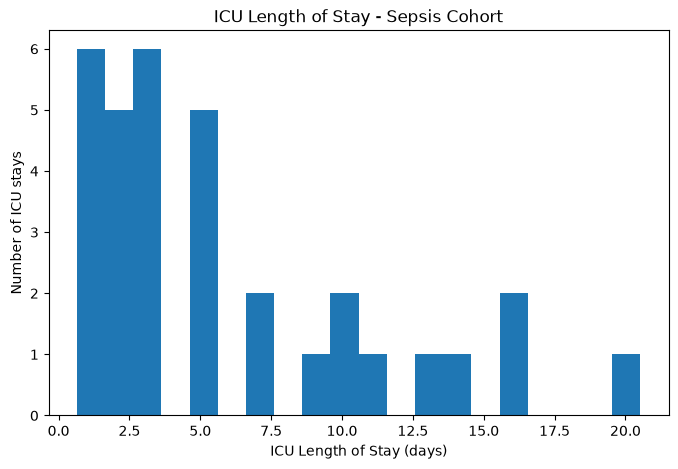

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    sepsis_icu["los"],
    bins=20
)

plt.xlabel("ICU Length of Stay (days)")
plt.ylabel("Number of ICU stays")
plt.title("ICU Length of Stay - Sepsis Cohort")

plt.show()

In [29]:
from pathlib import Path

# 1. Create the parent directories if they don't exist
Path("../data/processed").mkdir(parents=True, exist_ok=True)

# 2. Save your file
sepsis_icu.to_csv(
    "../data/processed/sepsis_icu_cohort_demo.csv",
    index=False
)
print("Saved:", len(sepsis_icu), "ICU stays")


Saved: 33 ICU stays


In [30]:
sepsis_subjects = sorted(
    sepsis_icu["subject_id"].unique()
)

print("Number of sepsis patients:", len(sepsis_subjects))

print("\nSubject IDs:")
for sid in sepsis_subjects:
    print(sid)

Number of sepsis patients: 17

Subject IDs:
10002428
10003400
10004235
10007818
10007928
10009049
10015860
10018081
10019003
10020740
10020786
10020944
10031757
10035631
10037861
10037975
10039708


In [31]:
waveform_candidates = pd.DataFrame({
    "subject_id": sepsis_subjects
})

waveform_candidates.to_csv(
    "../data/processed/sepsis_waveform_candidates.csv",
    index=False
)

display(waveform_candidates)

,subject_id
0,10002428
1,10003400
2,10004235
3,10007818
4,10007928
5,10009049
6,10015860
7,10018081
8,10019003
9,10020740


In [32]:
ecg_matches = d_items[
    d_items["label"]
    .fillna("")
    .str.contains(
        "ecg|electrocard|ekg|rhythm",
        case=False,
        na=False
    )
]

display(
    ecg_matches[
        ["itemid", "label", "abbreviation", "unitname", "category"]
    ].to_string(index=False)
)

' itemid        label abbreviation unitname            category\n 220048 Heart Rhythm Heart Rhythm      NaN Routine Vital Signs\n 225402          EKG          EKG      NaN        4-Procedures'

In [33]:
GCS_ITEMIDS = [
    223901,  # Motor
    223900,  # Verbal
    220739   # Eye
]

gcs_events = chartevents[
    chartevents["itemid"].isin(GCS_ITEMIDS)
].copy()

print("GCS events in current 10k sample:", len(gcs_events))

display(
    gcs_events[
        [
            "subject_id",
            "hadm_id",
            "stay_id",
            "charttime",
            "itemid",
            "value",
            "valuenum"
        ]
    ].head(30)
)

GCS events in current 10k sample: 123


,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum
63,10005817,20626031,32604416,2132-12-16 00:00:00,223901,Obeys Commands,6.0
75,10005817,20626031,32604416,2132-12-16 00:00:00,220739,To Speech,3.0
84,10005817,20626031,32604416,2132-12-16 00:00:00,223900,Oriented,5.0
251,10005817,20626031,32604416,2132-12-16 08:00:00,220739,Spontaneously,4.0
273,10005817,20626031,32604416,2132-12-16 08:00:00,223900,Oriented,5.0
295,10005817,20626031,32604416,2132-12-16 08:00:00,223901,Obeys Commands,6.0
440,10005817,20626031,32604416,2132-12-16 12:00:00,220739,Spontaneously,4.0
511,10005817,20626031,32604416,2132-12-16 12:00:00,223900,Oriented,5.0
533,10005817,20626031,32604416,2132-12-16 12:00:00,223901,Obeys Commands,6.0
582,10005817,20626031,32604416,2132-12-16 16:00:00,223900,Oriented,5.0


In [34]:
from pathlib import Path

icu_path = Path("../data/raw/mimic-iv/icu")

print(list(icu_path.iterdir()))

[PosixPath('../data/raw/mimic-iv/icu/datetimeevents.csv.gz'), PosixPath('../data/raw/mimic-iv/icu/index.html'), PosixPath('../data/raw/mimic-iv/icu/caregiver.csv.gz'), PosixPath('../data/raw/mimic-iv/icu/ingredientevents.csv.gz'), PosixPath('../data/raw/mimic-iv/icu/inputevents.csv.gz'), PosixPath('../data/raw/mimic-iv/icu/procedureevents.csv.gz'), PosixPath('../data/raw/mimic-iv/icu/d_items.csv.gz'), PosixPath('../data/raw/mimic-iv/icu/chartevents.csv.gz'), PosixPath('../data/raw/mimic-iv/icu/icustays.csv.gz'), PosixPath('../data/raw/mimic-iv/icu/outputevents.csv.gz')]


In [35]:
TARGET_ITEMS = {
    "heart_rate": 220045,
    "map": 220052,
    "resp_rate": 220210,
    "gcs_motor": 223901,
    "gcs_verbal": 223900,
    "gcs_eye": 220739,
}

TARGET_ITEMIDS = list(TARGET_ITEMS.values())

print(TARGET_ITEMS)

{'heart_rate': 220045, 'map': 220052, 'resp_rate': 220210, 'gcs_motor': 223901, 'gcs_verbal': 223900, 'gcs_eye': 220739}


In [38]:
import pandas as pd

chartevents_path = "../data/raw/mimic-iv/icu/chartevents.csv.gz"

needed_columns = [
    "subject_id",
    "hadm_id",
    "stay_id",
    "charttime",
    "itemid",
    "value",
    "valuenum",
    "valueuom",
]

ce = pd.read_csv(
    chartevents_path,
    compression="gzip",
    usecols=needed_columns,
    low_memory=False
)

print("Loaded rows:", len(ce))

Loaded rows: 668862


In [39]:
sepsis_stay_ids = set(
    sepsis_icu["stay_id"].astype(int)
)

clinical_events = ce[
    ce["stay_id"].isin(sepsis_stay_ids)
    &
    ce["itemid"].isin(TARGET_ITEMIDS)
].copy()

print("Relevant clinical events:", len(clinical_events))

print(
    "Unique ICU stays:",
    clinical_events["stay_id"].nunique()
)

print(
    "Unique patients:",
    clinical_events["subject_id"].nunique()
)

Relevant clinical events: 16718
Unique ICU stays: 33
Unique patients: 17


In [40]:
item_to_feature = {
    220045: "heart_rate",
    220052: "map",
    220210: "resp_rate",
    223901: "gcs_motor",
    223900: "gcs_verbal",
    220739: "gcs_eye",
}

clinical_events["feature"] = clinical_events["itemid"].map(
    item_to_feature
)

clinical_events["charttime"] = pd.to_datetime(
    clinical_events["charttime"]
)

clinical_events = clinical_events.sort_values(
    ["stay_id", "charttime"]
)

print(clinical_events["feature"].value_counts())

display(clinical_events.head(30))

feature
heart_rate    5414
resp_rate     5414
map           2582
gcs_eye       1106
gcs_verbal    1103
gcs_motor     1099
Name: count, dtype: int64


,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom,feature
324418,10031757,28477280,30458995,2137-10-12 22:46:00,220045,62,62.0,bpm,heart_rate
324419,10031757,28477280,30458995,2137-10-12 22:46:00,220210,17,17.0,insp/min,resp_rate
322391,10031757,28477280,30458995,2137-10-12 23:00:00,220210,18,18.0,insp/min,resp_rate
322398,10031757,28477280,30458995,2137-10-12 23:00:00,220045,60,60.0,bpm,heart_rate
324375,10031757,28477280,30458995,2137-10-12 23:41:00,220045,65,65.0,bpm,heart_rate
324377,10031757,28477280,30458995,2137-10-12 23:41:00,220210,19,19.0,insp/min,resp_rate
322403,10031757,28477280,30458995,2137-10-13 00:00:00,220045,66,66.0,bpm,heart_rate
322409,10031757,28477280,30458995,2137-10-13 00:00:00,220210,16,16.0,insp/min,resp_rate
324345,10031757,28477280,30458995,2137-10-13 00:40:00,220052,-8,-8.0,mmHg,map
324507,10031757,28477280,30458995,2137-10-13 00:51:00,223900,Oriented,5.0,NaN,gcs_verbal


In [41]:
coverage = (
    clinical_events
    .groupby("feature")
    .agg(
        observations=("valuenum", "count"),
        patients=("subject_id", "nunique"),
        stays=("stay_id", "nunique"),
        start=("charttime", "min"),
        end=("charttime", "max")
    )
    .sort_values("observations", ascending=False)
)

display(coverage)

,observations,patients,stays,start,end
feature,,,,,
heart_rate,5414,17,33,2116-02-28 18:52:00,2196-02-29 15:00:00
resp_rate,5414,17,33,2116-02-28 18:52:00,2196-02-29 15:00:00
map,2582,12,15,2116-02-29 21:47:00,2196-02-26 03:00:00
gcs_eye,1106,17,33,2116-02-28 20:00:00,2196-02-29 12:00:00
gcs_verbal,1103,17,33,2116-02-28 20:00:00,2196-02-29 12:00:00
gcs_motor,1099,17,33,2116-02-28 20:00:00,2196-02-29 12:00:00


In [42]:
gcs = (
    clinical_events[
        clinical_events["feature"].isin(
            ["gcs_eye", "gcs_verbal", "gcs_motor"]
        )
    ]
    .pivot_table(
        index=["subject_id", "hadm_id", "stay_id", "charttime"],
        columns="feature",
        values="valuenum",
        aggfunc="last"
    )
    .reset_index()
)

gcs.columns.name = None

print(gcs.shape)

display(gcs.head(20))

(1107, 7)


,subject_id,hadm_id,stay_id,charttime,gcs_eye,gcs_motor,gcs_verbal
0,10002428,20321825,34807493,2156-04-30 22:43:00,4.0,5.0,4.0
1,10002428,20321825,34807493,2156-05-01 06:26:00,3.0,5.0,3.0
2,10002428,20321825,34807493,2156-05-01 08:00:00,3.0,6.0,5.0
3,10002428,20321825,34807493,2156-05-01 12:00:00,3.0,6.0,4.0
4,10002428,20321825,34807493,2156-05-01 16:17:00,4.0,6.0,4.0
5,10002428,20321825,34807493,2156-05-01 19:24:00,3.0,6.0,5.0
6,10002428,20321825,34807493,2156-05-02 00:18:00,3.0,6.0,5.0
7,10002428,20321825,34807493,2156-05-02 08:00:00,4.0,6.0,5.0
8,10002428,20321825,34807493,2156-05-02 12:00:00,4.0,6.0,5.0
9,10002428,20321825,34807493,2156-05-02 16:54:00,3.0,6.0,5.0


In [43]:
gcs["gcs_total"] = (
    gcs["gcs_eye"]
    + gcs["gcs_verbal"]
    + gcs["gcs_motor"]
)

display(
    gcs[
        [
            "subject_id",
            "stay_id",
            "charttime",
            "gcs_eye",
            "gcs_verbal",
            "gcs_motor",
            "gcs_total",
        ]
    ].head(30)
)

,subject_id,stay_id,charttime,gcs_eye,gcs_verbal,gcs_motor,gcs_total
0,10002428,34807493,2156-04-30 22:43:00,4.0,4.0,5.0,13.0
1,10002428,34807493,2156-05-01 06:26:00,3.0,3.0,5.0,11.0
2,10002428,34807493,2156-05-01 08:00:00,3.0,5.0,6.0,14.0
3,10002428,34807493,2156-05-01 12:00:00,3.0,4.0,6.0,13.0
4,10002428,34807493,2156-05-01 16:17:00,4.0,4.0,6.0,14.0
5,10002428,34807493,2156-05-01 19:24:00,3.0,5.0,6.0,14.0
6,10002428,34807493,2156-05-02 00:18:00,3.0,5.0,6.0,14.0
7,10002428,34807493,2156-05-02 08:00:00,4.0,5.0,6.0,15.0
8,10002428,34807493,2156-05-02 12:00:00,4.0,5.0,6.0,15.0
9,10002428,34807493,2156-05-02 16:54:00,3.0,5.0,6.0,14.0


In [44]:
print(clinical_events.shape)
print(clinical_events["stay_id"].nunique())
print(clinical_events["subject_id"].nunique())

(16718, 9)
33
17


In [45]:
print("GCS dataframe shape:", gcs.shape)

display(
    gcs[
        [
            "subject_id",
            "hadm_id",
            "stay_id",
            "charttime",
            "gcs_eye",
            "gcs_verbal",
            "gcs_motor",
        ]
    ].head(30)
)

GCS dataframe shape: (1107, 8)


,subject_id,hadm_id,stay_id,charttime,gcs_eye,gcs_verbal,gcs_motor
0,10002428,20321825,34807493,2156-04-30 22:43:00,4.0,4.0,5.0
1,10002428,20321825,34807493,2156-05-01 06:26:00,3.0,3.0,5.0
2,10002428,20321825,34807493,2156-05-01 08:00:00,3.0,5.0,6.0
3,10002428,20321825,34807493,2156-05-01 12:00:00,3.0,4.0,6.0
4,10002428,20321825,34807493,2156-05-01 16:17:00,4.0,4.0,6.0
5,10002428,20321825,34807493,2156-05-01 19:24:00,3.0,5.0,6.0
6,10002428,20321825,34807493,2156-05-02 00:18:00,3.0,5.0,6.0
7,10002428,20321825,34807493,2156-05-02 08:00:00,4.0,5.0,6.0
8,10002428,20321825,34807493,2156-05-02 12:00:00,4.0,5.0,6.0
9,10002428,20321825,34807493,2156-05-02 16:54:00,3.0,5.0,6.0


In [46]:
gcs["gcs_total"] = (
    gcs["gcs_eye"]
    + gcs["gcs_verbal"]
    + gcs["gcs_motor"]
)

print("GCS observations:", len(gcs))
print("Patients:", gcs["subject_id"].nunique())
print("ICU stays:", gcs["stay_id"].nunique())

display(
    gcs[
        [
            "subject_id",
            "stay_id",
            "charttime",
            "gcs_eye",
            "gcs_verbal",
            "gcs_motor",
            "gcs_total",
        ]
    ].head(30)
)

GCS observations: 1107
Patients: 17
ICU stays: 33


,subject_id,stay_id,charttime,gcs_eye,gcs_verbal,gcs_motor,gcs_total
0,10002428,34807493,2156-04-30 22:43:00,4.0,4.0,5.0,13.0
1,10002428,34807493,2156-05-01 06:26:00,3.0,3.0,5.0,11.0
2,10002428,34807493,2156-05-01 08:00:00,3.0,5.0,6.0,14.0
3,10002428,34807493,2156-05-01 12:00:00,3.0,4.0,6.0,13.0
4,10002428,34807493,2156-05-01 16:17:00,4.0,4.0,6.0,14.0
5,10002428,34807493,2156-05-01 19:24:00,3.0,5.0,6.0,14.0
6,10002428,34807493,2156-05-02 00:18:00,3.0,5.0,6.0,14.0
7,10002428,34807493,2156-05-02 08:00:00,4.0,5.0,6.0,15.0
8,10002428,34807493,2156-05-02 12:00:00,4.0,5.0,6.0,15.0
9,10002428,34807493,2156-05-02 16:54:00,3.0,5.0,6.0,14.0


In [47]:
# Basic GCS statistics
print("GCS total statistics:")
display(gcs["gcs_total"].describe())

print("\nMissing values:")
display(gcs[[
    "gcs_eye",
    "gcs_verbal",
    "gcs_motor",
    "gcs_total"
]].isna().sum())

GCS total statistics:


count    1098.000000
mean       10.959016
std         3.806768
min         3.000000
25%         9.000000
50%        11.000000
75%        15.000000
max        15.000000
Name: gcs_total, dtype: float64


Missing values:


gcs_eye       1
gcs_verbal    4
gcs_motor     8
gcs_total     9
dtype: int64

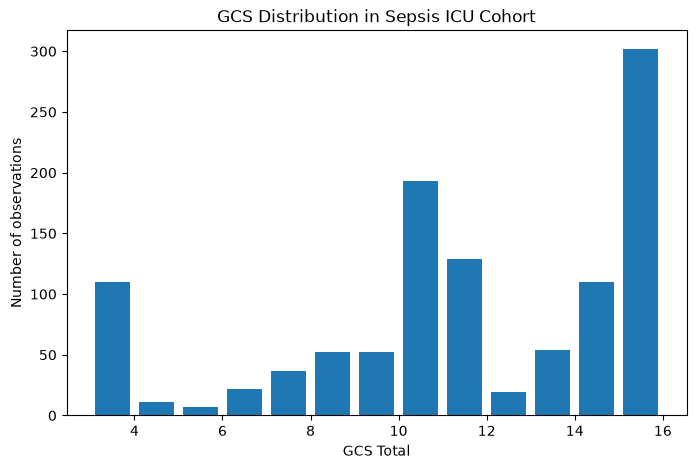

In [48]:
# Distribution of GCS total scores
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    gcs["gcs_total"].dropna(),
    bins=range(
        int(gcs["gcs_total"].min()),
        int(gcs["gcs_total"].max()) + 2
    ),
    rwidth=0.8
)

plt.xlabel("GCS Total")
plt.ylabel("Number of observations")
plt.title("GCS Distribution in Sepsis ICU Cohort")

plt.show()

In [49]:
# Number of GCS observations per ICU stay

gcs_coverage = (
    gcs.groupby(["subject_id", "stay_id"])
    .agg(
        observations=("gcs_total", "count"),
        start=("charttime", "min"),
        end=("charttime", "max"),
        min_gcs=("gcs_total", "min"),
        max_gcs=("gcs_total", "max"),
    )
    .reset_index()
)

gcs_coverage["duration_hours"] = (
    gcs_coverage["end"] - gcs_coverage["start"]
).dt.total_seconds() / 3600

display(
    gcs_coverage.sort_values(
        "duration_hours",
        ascending=False
    )
)

,subject_id,stay_id,observations,start,end,min_gcs,max_gcs,duration_hours
8,10007818,32359580,115,2146-06-22 13:00:00,2146-07-12 16:47:00,3.0,15.0,483.783333
30,10039708,33281088,91,2140-01-23 18:00:00,2140-02-08 20:00:00,7.0,15.0,386.000000
6,10003400,38383343,83,2137-08-17 18:00:00,2137-09-02 08:00:00,6.0,15.0,374.000000
13,10018081,37293400,86,2133-12-18 20:00:00,2134-01-01 12:00:00,3.0,15.0,328.000000
4,10003400,32128372,68,2137-02-26 00:30:00,2137-03-10 08:00:00,3.0,15.0,295.500000
2,10002428,35479615,67,2156-05-11 17:00:00,2156-05-22 12:15:00,6.0,15.0,259.250000
28,10037861,34531557,94,2117-03-14 21:00:00,2117-03-24 20:00:00,3.0,10.0,239.000000
27,10035631,30932571,61,2116-02-28 20:00:00,2116-03-09 16:00:00,3.0,15.0,236.000000
24,10020944,30757476,43,2131-02-27 17:00:00,2131-03-08 08:05:00,3.0,15.0,207.083333
20,10020740,35026312,38,2150-03-11 16:30:00,2150-03-18 20:57:00,5.0,15.0,172.450000


In [50]:
# Sort observations chronologically
gcs_sorted = gcs.sort_values(
    ["stay_id", "charttime"]
).copy()

# Previous GCS within each ICU stay
gcs_sorted["previous_gcs"] = (
    gcs_sorted
    .groupby("stay_id")["gcs_total"]
    .shift(1)
)

# Change from previous recorded GCS
gcs_sorted["gcs_change"] = (
    gcs_sorted["gcs_total"]
    - gcs_sorted["previous_gcs"]
)

display(
    gcs_sorted[
        [
            "subject_id",
            "stay_id",
            "charttime",
            "gcs_total",
            "previous_gcs",
            "gcs_change"
        ]
    ]
    .dropna(subset=["gcs_change"])
    .sort_values("gcs_change")
    .head(30)
)

,subject_id,stay_id,charttime,gcs_total,previous_gcs,gcs_change
338,10007818,32359580,2146-06-22 21:00:00,3.0,12.0,-9.0
724,10020740,35889503,2150-03-27 08:00:00,3.0,11.0,-8.0
1063,10039708,33281088,2140-02-01 16:55:00,7.0,14.0,-7.0
825,10035631,30932571,2116-02-29 16:00:00,7.0,14.0,-7.0
231,10003400,38383343,2137-08-17 20:44:00,7.0,14.0,-7.0
259,10003400,38383343,2137-08-23 08:00:00,8.0,14.0,-6.0
861,10035631,30932571,2116-03-06 12:42:00,5.0,11.0,-6.0
922,10037861,34531557,2117-03-17 14:00:00,3.0,8.0,-5.0
919,10037861,34531557,2117-03-17 10:02:00,3.0,8.0,-5.0
412,10007818,32359580,2146-07-05 20:00:00,10.0,15.0,-5.0


In [51]:
print("Missing GCS rows:")

display(
    gcs[
        gcs[
            ["gcs_eye", "gcs_verbal", "gcs_motor"]
        ].isna().any(axis=1)
    ][
        [
            "subject_id",
            "stay_id",
            "charttime",
            "gcs_eye",
            "gcs_verbal",
            "gcs_motor",
            "gcs_total",
        ]
    ]
)

Missing GCS rows:


,subject_id,stay_id,charttime,gcs_eye,gcs_verbal,gcs_motor,gcs_total
16,10002428,35479615,2156-05-12 05:00:00,1.0,1.0,NaN,NaN
319,10004235,34100191,2196-02-26 09:00:00,NaN,NaN,5.0,NaN
320,10004235,34100191,2196-02-26 09:56:00,4.0,1.0,NaN,NaN
652,10020740,31077365,2150-04-03 08:00:00,3.0,NaN,NaN,NaN
750,10020944,30757476,2131-02-27 17:00:00,1.0,1.0,NaN,NaN
986,10037975,39061571,2185-01-20 04:26:00,2.0,NaN,NaN,NaN
989,10037975,39061571,2185-01-20 20:53:00,3.0,1.0,NaN,NaN
990,10037975,39061571,2185-01-21 00:46:00,2.0,NaN,NaN,NaN
1015,10039708,33281088,2140-01-23 18:00:00,4.0,5.0,NaN,NaN


In [52]:
print("GCS total distribution:")
display(
    gcs["gcs_total"]
    .value_counts(dropna=False)
    .sort_index()
)

GCS total distribution:


gcs_total
3.0     110
4.0      11
5.0       7
6.0      22
7.0      37
8.0      52
9.0      52
10.0    193
11.0    129
12.0     19
13.0     54
14.0    110
15.0    302
NaN       9
Name: count, dtype: int64

In [53]:
print("GCS range:")

print("Minimum:", gcs["gcs_total"].min())
print("Maximum:", gcs["gcs_total"].max())

GCS range:
Minimum: 3.0
Maximum: 15.0


In [54]:
gcs_sorted = gcs.sort_values(
    ["stay_id", "charttime"]
).copy()

gcs_sorted["previous_gcs"] = (
    gcs_sorted
    .groupby("stay_id")["gcs_total"]
    .shift(1)
)

gcs_sorted["gcs_change"] = (
    gcs_sorted["gcs_total"]
    - gcs_sorted["previous_gcs"]
)

display(
    gcs_sorted[
        [
            "subject_id",
            "stay_id",
            "charttime",
            "gcs_total",
            "previous_gcs",
            "gcs_change"
        ]
    ]
    .dropna(subset=["gcs_change"])
    .sort_values("gcs_change")
    .head(30)
)

,subject_id,stay_id,charttime,gcs_total,previous_gcs,gcs_change
338,10007818,32359580,2146-06-22 21:00:00,3.0,12.0,-9.0
724,10020740,35889503,2150-03-27 08:00:00,3.0,11.0,-8.0
1063,10039708,33281088,2140-02-01 16:55:00,7.0,14.0,-7.0
825,10035631,30932571,2116-02-29 16:00:00,7.0,14.0,-7.0
231,10003400,38383343,2137-08-17 20:44:00,7.0,14.0,-7.0
259,10003400,38383343,2137-08-23 08:00:00,8.0,14.0,-6.0
861,10035631,30932571,2116-03-06 12:42:00,5.0,11.0,-6.0
922,10037861,34531557,2117-03-17 14:00:00,3.0,8.0,-5.0
919,10037861,34531557,2117-03-17 10:02:00,3.0,8.0,-5.0
412,10007818,32359580,2146-07-05 20:00:00,10.0,15.0,-5.0


In [55]:
print("GCS change distribution:")
display(
    gcs_sorted["gcs_change"]
    .dropna()
    .describe()
)

print("Counts by GCS change:")

display(
    gcs_sorted["gcs_change"]
    .dropna()
    .value_counts()
    .sort_index()
)

GCS change distribution:


count    1060.000000
mean        0.087736
std         1.402426
min        -9.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         7.000000
Name: gcs_change, dtype: float64

Counts by GCS change:


gcs_change
-9.0      1
-8.0      1
-7.0      3
-6.0      2
-5.0      5
-4.0     13
-3.0      8
-2.0     26
-1.0     77
 0.0    735
 1.0    110
 2.0     28
 3.0     24
 4.0     11
 5.0      8
 6.0      5
 7.0      3
Name: count, dtype: int64

In [56]:
for threshold in [-1, -2, -3, -4, -5]:
    count = (
        gcs_sorted["gcs_change"] <= threshold
    ).sum()

    stays = (
        gcs_sorted.loc[
            gcs_sorted["gcs_change"] <= threshold,
            "stay_id"
        ]
        .nunique()
    )

    patients = (
        gcs_sorted.loc[
            gcs_sorted["gcs_change"] <= threshold,
            "subject_id"
        ]
        .nunique()
    )

    print(
        f"Threshold ΔGCS <= {threshold}: "
        f"{count} events | "
        f"{stays} ICU stays | "
        f"{patients} patients"
    )

Threshold ΔGCS <= -1: 136 events | 23 ICU stays | 13 patients
Threshold ΔGCS <= -2: 59 events | 17 ICU stays | 10 patients
Threshold ΔGCS <= -3: 33 events | 12 ICU stays | 10 patients
Threshold ΔGCS <= -4: 25 events | 11 ICU stays | 9 patients
Threshold ΔGCS <= -5: 12 events | 7 ICU stays | 7 patients


In [57]:
# Add ICU admission time
sepsis_icu["intime"] = pd.to_datetime(
    sepsis_icu["intime"]
)

gcs_analysis = gcs_sorted.merge(
    sepsis_icu[
        ["stay_id", "intime", "outtime"]
    ],
    on="stay_id",
    how="left"
)

gcs_analysis["hours_from_icu_admission"] = (
    gcs_analysis["charttime"] -
    gcs_analysis["intime"]
).dt.total_seconds() / 3600

display(
    gcs_analysis[
        gcs_analysis["gcs_change"] <= -3
    ][
        [
            "subject_id",
            "stay_id",
            "charttime",
            "hours_from_icu_admission",
            "previous_gcs",
            "gcs_total",
            "gcs_change"
        ]
    ]
    .sort_values("hours_from_icu_admission")
)

,subject_id,stay_id,charttime,hours_from_icu_admission,previous_gcs,gcs_total,gcs_change
1042,10002428,38875437,2156-04-19 19:30:00,1.311389,8.0,4.0,-4.0
948,10003400,38383343,2137-08-17 20:44:00,3.123056,14.0,7.0,-7.0
221,10007818,32359580,2146-06-22 21:00:00,9.225278,12.0,3.0,-9.0
61,10035631,30932571,2116-02-29 16:00:00,21.277778,14.0,7.0,-7.0
1048,10002428,38875437,2156-04-20 20:46:00,26.578056,11.0,8.0,-3.0
738,10002428,35479615,2156-05-12 20:25:00,29.590556,14.0,10.0,-4.0
830,10020740,35889503,2150-03-27 08:00:00,37.617778,11.0,3.0,-8.0
65,10035631,30932571,2116-03-01 08:45:00,38.027778,7.0,3.0,-4.0
490,10004235,34100191,2196-02-26 20:00:00,50.883333,11.0,8.0,-3.0
72,10035631,30932571,2116-03-02 08:00:00,61.277778,10.0,6.0,-4.0


In [58]:
from pathlib import Path

# Make sure processed directory exists
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Save the filtered clinical events
clinical_events.to_csv(
    processed_dir / "sepsis_clinical_events_demo.csv",
    index=False
)

print("Saved successfully!")
print("Path:", processed_dir / "sepsis_clinical_events_demo.csv")
print("Shape:", clinical_events.shape)

Saved successfully!
Path: ../data/processed/sepsis_clinical_events_demo.csv
Shape: (16718, 9)


In [59]:
gcs.to_csv(
    processed_dir / "sepsis_gcs_trajectory_demo.csv",
    index=False
)

print("GCS dataset saved!")
print("Shape:", gcs.shape)

GCS dataset saved!
Shape: (1107, 8)
